<span style="color:green; font-size:26px; font-weight:bold;">MODELO 2: </span>

<span style="color:green; font-size:33px; font-weight:bold;">LOGISTIC REGRESSION</span>

________________________________________________________________________________________________________________________________


### Justificación   

Tras una primera fase de análisis exploratorio y modelización mediante técnicas de regresión, se observó que la variable objetivo, Satisfacción general con la vida, presenta una distribución claramente concentrada en los valores altos de la escala (media = 7,31 sobre 10). Aunque la aproximación mediante regresión permitió identificar los factores más relacionados con el bienestar subjetivo y cuantificar su influencia, la interpretación práctica de una predicción numérica exacta resulta limitada desde el punto de vista de la aplicación del modelo.

Por este motivo, se decidió reformular el problema como una tarea de clasificación. El objetivo pasa a ser identificar si una persona presenta o no un nivel elevado de satisfacción con la vida, lo que facilita tanto la interpretación de los resultados como su posible aplicación en contextos reales.

Para ello se construyó una nueva variable binaria denominada "Bienestar_alto", donde los valores de satisfacción entre 0 y 7 se clasifican como 0 (ausencia de bienestar elevado) y los valores entre 8 y 10 como 1 (bienestar elevado). Este punto de corte se seleccionó por varios motivos. En primer lugar, el valor 8 representa un nivel claramente alto de satisfacción dentro de la escala utilizada. En segundo lugar, la distribución resultante genera dos grupos muy equilibrados (aproximadamente 46% frente a 54% de los registros), lo que favorece el entrenamiento y evaluación de modelos de clasificación. Y en tercer lugar, tomamos la media, situada entre el 7 y el 8 (7,31) como punto de corte, entre los más satisfechos y los menos satisfechos con su vida.

Este nuevo enfoque permite abordar una pregunta más relevante desde el punto de vista predictivo: determinar qué características personales, sociales y económicas permiten identificar a las personas con una alta probabilidad de alcanzar elevados niveles de bienestar subjetivo.

Además, el análisis de regresión realizado previamente no pierde utilidad, sino que complementa esta nueva fase del estudio, ya que proporciona evidencia sobre los factores más asociados a la satisfacción vital y sirve como base para la selección de variables utilizadas en los modelos de clasificación.



In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [25]:
df_modelo = pd.read_csv("../1_Data/processed.csv", sep = ",")

df_modelo

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5279,1,1,4,1,1,2,1,3,7,9,8,7,8,9,8,8,4,6,6
5280,1,6,7,4,1,1,3,1,6,8,7,3,6,7,10,8,3,5,6
5281,1,6,3,5,1,2,3,2,4,5,5,5,5,8,5,7,3,5,5
5282,1,1,5,4,1,1,1,3,8,8,9,8,8,8,7,8,3,7,5


In [26]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 5284 entries, 0 to 5283
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Terr_hist              5284 non-null   int64
 1   Sexo                   5284 non-null   int64
 2   Edad_interv            5284 non-null   int64
 3   Lugar_nacim            5284 non-null   int64
 4   Nacionalidad           5284 non-null   int64
 5   Nivel_estudios         5284 non-null   int64
 6   Actividad              5284 non-null   int64
 7   Tipo_hogar             5284 non-null   int64
 8   Target_Satisfacc_Vida  5284 non-null   int64
 9   Satisf_relac_pers      5284 non-null   int64
 10  Sentido_propia_vida    5284 non-null   int64
 11  Satisf_econom_domest   5284 non-null   int64
 12  Valor_Estado_animo     5284 non-null   int64
 13  Satisf_vivienda        5284 non-null   int64
 14  Satisf_tiempo_disp     5284 non-null   int64
 15  Satisf_viv_y_entorno   5284 non-null   int64
 16 

In [27]:
df_modelo.describe(include='all')

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
count,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000
mean,27.478236,3.649508,4.648940,1.975208,1.222369,1.950227,2.026495,2.322104,7.313588,7.793906,7.626041,6.989402,6.411052,7.609765,6.913134,7.322861,2.921840,6.453255,4.495458
std,19.050649,2.495762,1.814499,1.515505,1.030825,0.899861,0.979855,1.240506,1.770229,1.698033,1.803999,1.812392,1.477396,1.832021,2.235819,1.419637,0.767344,1.994762,2.048203
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,6.000000,5.000000,7.000000,6.000000,7.000000,3.000000,5.000000,3.000000
50%,20.000000,6.000000,5.000000,1.000000,1.000000,2.000000,2.000000,2.000000,8.000000,8.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000,3.000000,7.000000,5.000000
75%,48.000000,6.000000,6.000000,4.000000,1.000000,3.000000,3.000000,3.000000,8.000000,9.000000,9.000000,8.000000,7.000000,9.000000,8.000000,8.000000,3.000000,8.000000,6.000000
max,48.000000,6.000000,7.000000,5.000000,6.000000,3.000000,3.000000,5.000000,10.000000,10.000000,10.000000,10.000000,9.000000,10.000000,10.000000,10.000000,4.000000,10.000000,10.000000


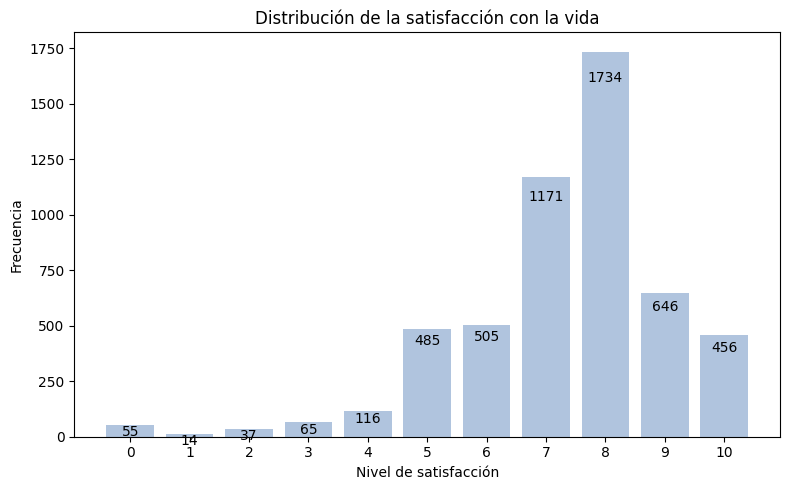

In [28]:
#Saco frecuencias y represento gráficamente la distribución de valores de la target para establecer los dos grupos de clasificación

frecuencias = df_modelo['Target_Satisfacc_Vida'].value_counts().sort_index()

plt.figure(figsize=(8,5))

bars = plt.bar(
    frecuencias.index,
    frecuencias.values,
    color='lightsteelblue'
)

# Etiquetas dentro de las barras
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura*0.95,
        f'{int(altura)}',
        ha='center',
        va='top'
    )

plt.title('Distribución de la satisfacción con la vida')
plt.xlabel('Nivel de satisfacción')
plt.ylabel('Frecuencia')

plt.xticks(frecuencias.index)

plt.tight_layout()
plt.show()

In [29]:
tabla_target = pd.DataFrame({
    'Frecuencia': df_modelo['Target_Satisfacc_Vida'].value_counts().sort_index()
})

tabla_target['Porcentaje'] = (
    tabla_target['Frecuencia'] /
    tabla_target['Frecuencia'].sum() * 100
).round(2)

tabla_target

,Frecuencia,Porcentaje
Target_Satisfacc_Vida,,
0,55,1.04
1,14,0.26
2,37,0.70
3,65,1.23
4,116,2.20
5,485,9.18
6,505,9.56
7,1171,22.16
8,1734,32.82


In [30]:
media_target = df_modelo['Target_Satisfacc_Vida'].mean()
media_target

np.float64(7.313588190764572)

In [31]:
df_modelo['Bienestar_alto'] = (
    df_modelo['Target_Satisfacc_Vida'] >= 8
).astype(int)

In [32]:
tabla_clases = pd.DataFrame({
    'Frecuencia': df_modelo['Bienestar_alto'].value_counts().sort_index()
})

tabla_clases['Porcentaje'] = (
    tabla_clases['Frecuencia'] /
    tabla_clases['Frecuencia'].sum() * 100
).round(2)

tabla_clases.index = [
    'No bienestar alto (0-7)',
    'Bienestar alto (8-10)'
]

tabla_clases

,Frecuencia,Porcentaje
No bienestar alto (0-7),2448,46.33
Bienestar alto (8-10),2836,53.67


In [33]:
# Guardo el dataframe final para modelado
df_modelo.to_csv('processed_clas.csv', index=False, encoding='utf-8')
df_modelo.head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub,Bienestar_alto
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6,1
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2,1
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3,1
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4,1
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5,1


In [34]:
#Cargo nuevo dataset que utilizaré a a partir de ahora para trabajar con modelos de clasificación

df_mod_clas = pd.read_csv('../1_Data/processed_clas.csv')
df_mod_clas.head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub,Bienestar_alto
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6,1
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2,1
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3,1
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4,1
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5,1


In [35]:
# Variables predictoras
X = df_mod_clas.drop(
    columns=['Terr_hist', 'Sexo', 'Edad_interv', 'Lugar_nacim', 'Nacionalidad',
       'Nivel_estudios', 'Actividad', 'Tipo_hogar','Target_Satisfacc_Vida', 'Bienestar_alto']
)

# Variable objetivo
y = df_mod_clas['Bienestar_alto']

In [36]:
#separo en test y train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (5284, 10)
Dimensiones de y: (5284,)


In [37]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Bienestar_alto
1    0.536787
0    0.463213
Name: proportion, dtype: float64

Test:
Bienestar_alto
1    0.536424
0    0.463576
Name: proportion, dtype: float64


Aunque la Regresión Logística puede funcionar sin escalado, es recomendable mantener el mismo criterio para todos los modelos de clasificación. El escalador se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Creao y entreno el modelo
logreg = LogisticRegression(
    random_state=10
)

logreg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",10
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [40]:
#Realizo las predicciones
y_pred_log = logreg.predict(X_test_scaled)
y_pred_log

array([0, 1, 1, ..., 1, 1, 0], shape=(1057,))

In [41]:
#Métricas de evaluación

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.815
Precision: 0.819
Recall   : 0.840
F1-score : 0.829


Interpretación de las métricas:

La Regresión Logística obtuvo un accuracy del 81,5%, lo que indica una elevada capacidad para clasificar correctamente a los individuos según presenten o no niveles altos de bienestar. Asimismo, los valores de precision (81,9%), recall (84,0%) y F1-score (82,9%) muestran un rendimiento equilibrado y consistente del modelo. Estos resultados sugieren que las variables seleccionadas contienen información suficiente para discriminar adecuadamente entre individuos con alta satisfacción vital y el resto de la población.


Comparación con la regresión lineal:

La comparación directa no es posible porque son problemas distintos, pero sí podemos sacar una conclusión:

La regresión lineal explicaba aproximadamente un 59% de la variabilidad de la satisfacción vital (R² ≈ 0.59).
La clasificación logística consigue identificar correctamente el grupo de bienestar alto en más del 80% de los casos.

Por tanto, la reformulación del problema como clasificación parece estar funcionando muy bien.

In [42]:
#Matriz de confusión: 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[385 105]
 [ 91 476]]


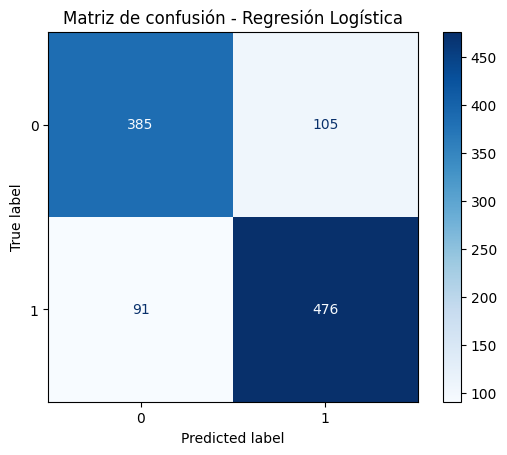

In [43]:
#Representación gráfica

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap='Blues'
)

plt.title('Matriz de confusión - Regresión Logística')
plt.show()

La matriz de confusión muestra que el modelo clasifica correctamente 385 individuos pertenecientes al grupo de menor bienestar y 476 individuos pertenecientes al grupo de bienestar elevado. Los errores de clasificación se distribuyen de forma relativamente equilibrada entre falsos positivos (105 casos) y falsos negativos (91 casos), lo que indica que el modelo no presenta un sesgo significativo hacia ninguna de las dos clases. Este comportamiento es coherente con los valores obtenidos en accuracy (81,5%), precision (81,9%) y recall (84,0%), confirmando la capacidad de la regresión logística para identificar adecuadamente a las personas con elevados niveles de satisfacción vital.

Este Logistic Regression ya se ha convertido en un modelo bastante serio para usar como benchmark. Para que Decision Tree, Random Forest o Gradient Boosting merezcan la pena, deberían superar claramente ese F1 ≈ 0.83

Nota: Se eliminaron las variables demográficas del conjunto de predictores al comprobarse que su inclusión no mejoraba el rendimiento del modelo. La comparación entre ambas configuraciones mostró diferencias mínimas en Accuracy, Precision, Recall y F1-score, por lo que se optó por mantener únicamente las variables relacionadas con el bienestar subjetivo, la situación económica, la salud y las relaciones sociales. El modelo se simplifica sin perder capacidad predictiva.